# Comparaison cartographies

## Initialisation

### Imports

In [2]:
import os
# import h5py
import cv2
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

import scienceplots
plt.style.use(['science', 'notebook', 'grid'])
from scipy.ndimage import gaussian_filter
from skimage import measure
import itertools
from sklearn.cluster import KMeans
from pathlib import Path

from TherMIFASOL.core.variables.GlobalVariables import (
    LAMBDA_NIR, T_SOLIDUS, T_LIQUIDUS, LINES_CRED, COLUMNS_CRED, FAC
)
from TherMIFASOL.core.variables.BoardCardFilterVariable import (
    params_clip, boundaries_data_selection, time_constant_parameters,
    params_first_order, boundaries_data_color, colors_plots_cordon
)
from TherMIFASOL.core.data_processing.PYROMETER_functions import (
    collect_data_pyrometer,
)
from TherMIFASOL.core.data_processing.CRED_functions import (
    load_cred_array, dl_to_thermo
)
from TherMIFASOL.core.data_processing.XIMEA_functions import (
    load_full_frame_nir, xiq_dl_to_flux_two_table, split_channel,
    xiq_bichromatic_temperature_field, xiq_emissivity_field, 
    apply_homographic_transformation
)
from TherMIFASOL.core.models.EmissivityEmpiricalLaws import (
    first_order_emissivity, wagner_inspired_emissivity, mean_absolute_image_difference
)
from TherMIFASOL.core.utils.visualization import (
    setup_contour_parameters
)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [3]:
PATH_DATA = "/media/dolle/Extreme SSD/DATA_MIFASOL/"
# Work path project
try:
    BASE_DIR = Path(__file__).resolve().parents[3]
except NameError:
    BASE_DIR = Path().resolve().parents[3]


# Path to data
#-------------------
data_path = os.path.join(
    PATH_DATA, "experiences/AddMultiSpectral/MUR2//"
)



# Calibration tables
#-------------------

#   CRED:
array_nuc = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/NUC/NUC_2pts_Temp550_WithNeutralDensity.npy"
        )
    )
array_calibration = np.load(
    os.path.join(
        BASE_DIR, "TherMIFASOL/resources/tables/FLUX/FLUX_IT40_deg1_NUC2.npy"
        )
    )

#   XIMEA:
XIMEA_NUC_table = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/nuc_NUC_LURPA.npy")
)

# Flux: IT3 --> 102 µs"
XIMEA_flux_table_Poly1 = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/table_flux_IT3_afterNUC1.npy")
)  ## Poly1: Linear flux/DL relationship ---> extrapolation
XIMEA_flux_table_Poly5 = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/table_flux_IT3_afterNUC5.npy")
)  ## Poly5: flux/DL relationship ---> interpolation
Low_limit_for_switch = np.load(
    os.path.join(BASE_DIR, "TherMIFASOL/resources/tables/XIMEA_TRAVAIL_EMMANUEL/LimiteBASSE_DL.npy")
)  # Limit for switching to interpolate side to extrapolate side


# Saving path
#------------
saving_path = os.path.join(BASE_DIR, "results/BoardFilter/WagnerLaw")

## Tools

### Loading homographic matrices
* matrix_H is a dictionary whose key is the channel identifier.
* matrix_H[channel] is a 3x3 matrix for the transformation.

In [4]:
with open(os.path.join(
    BASE_DIR, "TherMIFASOL/resources/tables/homographic_matrix/H_matrix.pkl"
), 'rb') as f:
    matrix_H = pickle.load(f)

### Pyrometer position mask
Mask of the pixels in the pyro's viewing area relative to the pyro's field of view (see png ./position_pyro/spot_pyro_spot.png).

In [5]:
mask_position_pyrometer = np.load(os.path.join(
    BASE_DIR, "TherMIFASOL/resources/tables/position_pyrometer/position_pyro_640x512.npy"
    )
)
RGBA_mask_position_pyrometer = np.zeros((512, 640, 4))
RGBA_mask_position_pyrometer[mask_position_pyrometer] = [1, 0, 0, 1] 

## Etude

### Wall description

#### Data recording during cord deposition

Data recording during the deposit of cords from 16 to 30 with 
identifiers from 1 to 16.

```python
f"./MUR2/CRED/CRED_normal_{i:05d}"
f"./MUR2/XIQ/XIQ_normal_{i:05d}"
```
(v : with gas / x : without gas)
| id cordon  | 16  | 17  | 18  | 19  | 20  | 21  | 22  | 23  | 24  | 25  | 26  | 27  | 28  | 29  | 30  |
|------------|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|-----|
| id cam     |  1  |  2  |  3  |  4  |  5  |  7  |  8  |  9  | 10  | 11  | 12  | 13  | 14  | 15  | 16  |
| Argon      |  v  |  v  |  v  |  v  |  v  |  x  |  x  |  x  |  x  |  v  |  v  |  v  |  v  |  v  |  v  |
| Pyrometer  | 16  | 17  | 18  | 19  | 20  | 21  | 22  | 23  | 24  | 25  | 26  | 27  | 28  | 29  | 30  |


Pyrometer profile for all layers from 1 to 30 with identifiers for
43 à 72.
```python
f"./MUR2/pyrometer/H322-14150_{i+42}.r2b"
```


#### Chose the indexes

In [6]:
bead_id_camera = 5  # CAMERA 
bead_id_pyrometer = 20  # Check correspondence table above

### Data time management

In [7]:
# Pyrometer
path_data_bead:str = os.path.join(data_path, f"pyrometer/cordon_{bead_id_pyrometer}.csv")
dict_data_bead:dict = collect_data_pyrometer(csv_path=path_data_bead)

temps_ = dict_data_bead['array time']
temp2C = dict_data_bead['array temp2C']
MAtemp2C = dict_data_bead['array MAtemp2C']
MONeps = dict_data_bead['array MAemissivity']

# CRED
path_data_CRED = os.path.join(data_path, f"CRED/CRED_normal_{bead_id_camera:05d}")
metadata_CRED=pd.read_csv(os.path.join(path_data_CRED, 'metadata.csv'), encoding='unicode_escape', sep=',')
tim_python_CRED=np.asarray(metadata_CRED['t(s)'])
id_im_CRED=np.asarray(metadata_CRED['ImageUniqueID'])

# Multi-spectral
path_data_XIQ = os.path.join(data_path, f"XIQ/XIQ_normal_{bead_id_camera:05d}")
metadata_XIQ=pd.read_csv(os.path.join(path_data_XIQ, 'metadata.csv'), encoding='unicode_escape', sep=',')
tim_python_XIQ=np.asarray(metadata_XIQ['t(s)'])
tim_XIQ=np.asarray(metadata_XIQ['XimeaSec']) + np.asarray(metadata_XIQ['XimeaUSec'])*1e-6 
id_im_XIQ=np.asarray(metadata_XIQ['ImageUniqueID'])

In [8]:
PERC = 0.75  # t = t_start + PERC * duration
duration_recording_data = min(tim_python_XIQ[-1], tim_python_CRED[-1])

# Lowest acquisition frequency for XIMEA : first to manage
ID_XIMEA_img = np.abs(tim_python_XIQ - PERC*duration_recording_data).argmin()
TIME_XIMEA_img = tim_python_XIQ[ID_XIMEA_img]

# Then we took the closest frame from CRED
ID_CRED_img = np.abs(tim_python_CRED - TIME_XIMEA_img).argmin()
TIME_CRED_img = tim_python_CRED[ID_CRED_img]

print(f"Duration recording: {duration_recording_data:.4f} s")
print(f"Percentage selected: {PERC*100} %")
print(f"XIMEA: {TIME_XIMEA_img:.4f} s -- id img: {ID_XIMEA_img:4d}")
print(f" CRED: {TIME_CRED_img:.4f} s -- id img: {ID_CRED_img:4d}")

Duration recording: 10.6265 s
Percentage selected: 75.0 %
XIMEA: 7.9627 s -- id img:  925
 CRED: 7.9620 s -- id img: 2165


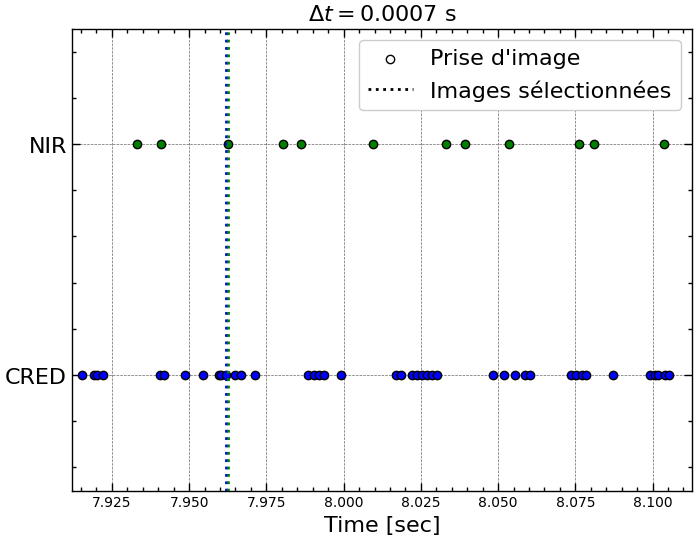

In [9]:
fig, ax = plt.subplots()

img_prise = [TIME_CRED_img, TIME_XIMEA_img]
extr = 0.05  # Marge pour l'axe X

# FRames chosen
ax.vlines(
    img_prise,
    ymin=-0.5,
    ymax=1.5,
    color=['b', 'g'],
    linestyles='dotted'
)

# Legends
ax.scatter([], [], facecolor='white', edgecolor='black', label="Prise d'image", marker='o')
ax.plot([], [], c='black', label="Images sélectionnées", linestyle='dotted')

# Dots representing frames
ax.scatter(tim_python_CRED, np.zeros(len(tim_python_CRED)), facecolor='blue', edgecolor='black')
ax.scatter(tim_python_XIQ, np.ones(len(tim_python_XIQ)), facecolor='green', edgecolor='black')

# Y-axis corrected
ax.set_yticks([0, 1])
ax.set_yticklabels(['CRED', 'NIR'])

# Setting axes
ax.set_ylim(-0.5, 1.5)
ax.set_xlim(min(img_prise) - extr, max(img_prise) + 3*extr)
ax.tick_params(axis='x', which='major', labelsize=10)
# Legends et labels
ax.legend()
ax.set_xlabel('Time [sec]')
ax.set_title(r"$\Delta t = $" + f"{np.abs(TIME_CRED_img - TIME_XIMEA_img):.4f} s")
ax.grid(True, linestyle='--', alpha=0.6)

plt.show()

### Image management

#### Ximea

In [10]:
XIMEA_frame_path = os.path.join(
    path_data_XIQ,
    f"{id_im_XIQ[ID_XIMEA_img]:06d}_{tim_python_XIQ[ID_XIMEA_img]:.3f}.npy",
)
# shape: 1088, 2048
XIMEA_im_dl_raw = load_full_frame_nir(
    frame_path=XIMEA_frame_path
    )

# full_frame_NUC_extrapole, full_frame_NUC_flux = ...
# shape: 1088, 2048
XIMEA_im_flux_extrapolate, XIMEA_im_flux_interpolate = xiq_dl_to_flux_two_table(
    full_scale_array=XIMEA_im_dl_raw,
    nuc_table=XIMEA_NUC_table,
    calibration_table_interpolated=XIMEA_flux_table_Poly5,
    calibration_table_extrapolate=XIMEA_flux_table_Poly1
    )


# Split channels --> img[canal, :, :]
# shape: 25, 217, 409
XIMEA_im_flux_extrapolate_split = split_channel(XIMEA_im_flux_extrapolate)

channel_i=0
channel_j=4
# shape: 217, 409
XIMEA_im_thermo = xiq_bichromatic_temperature_field(
    all_channels_split_flux=XIMEA_im_flux_extrapolate_split, 
    channel_i=channel_i, 
    channel_j=channel_j
)

# shape: 217, 409
XIMEA_im_emissivity = xiq_emissivity_field(
    all_channels_split_flux=XIMEA_im_flux_extrapolate_split, 
    channel=channel_i,
    bichromatic_temperature_array=XIMEA_im_thermo
)

# Rescaling 
channel_for_homographic_transformation = 0
XIMEA_im_thermo_rescaled = apply_homographic_transformation(
    array_to_rescale=XIMEA_im_thermo, 
    homographic_matrix=matrix_H[channel_for_homographic_transformation]
)
XIMEA_im_emissivity_rescaled = apply_homographic_transformation(
    array_to_rescale=XIMEA_im_emissivity, 
    homographic_matrix=matrix_H[channel_for_homographic_transformation]
)


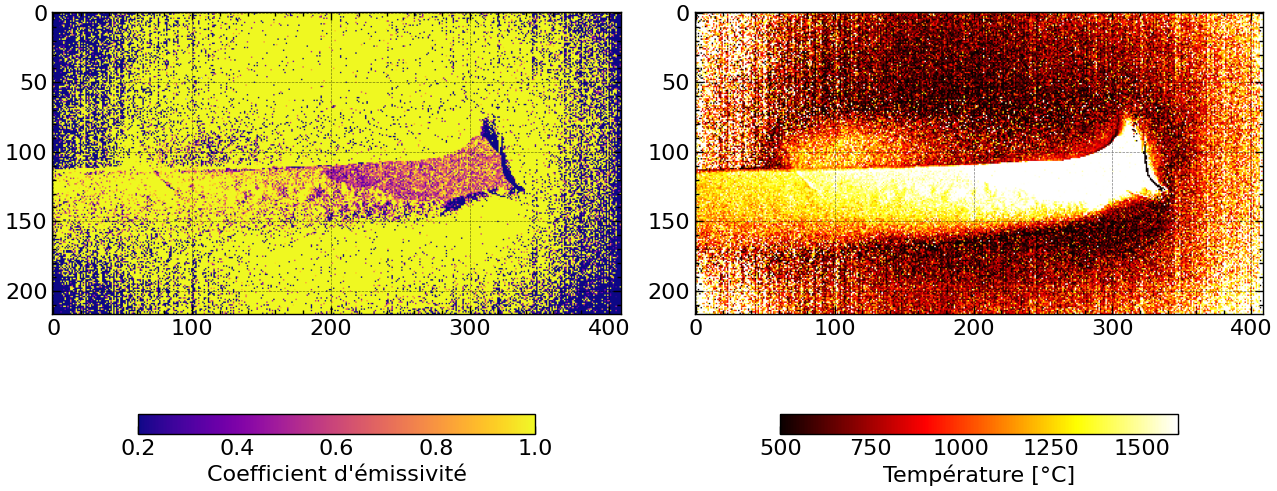

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,7))
im1 = ax1.imshow(XIMEA_im_emissivity, 'plasma', vmin=0.2, vmax=1)
cbar = plt.colorbar(im1, ax=ax1, orientation='horizontal', shrink=0.7)
cbar.set_label("Coefficient d'émissivité")

im2 = ax2.imshow(XIMEA_im_thermo, 'hot', vmin=500, vmax=1600)
cbar = plt.colorbar(im2, ax=ax2, orientation='horizontal', shrink=0.7)
cbar.set_label("Température [°C]")
fig.tight_layout()
plt.show()

#### CRED

In [12]:
path_frame_chosen_CRED = os.path.join(
    path_data_CRED, 
    f'{id_im_CRED[ID_CRED_img]:06d}_{tim_python_CRED[ID_CRED_img]:.3f}.npy'
)
CRED_im_dl_raw = load_cred_array(path_frame_chosen_CRED)

#### Champ d'émissivité uniform

In [13]:
eps0 = 0.73
CRED_im_thermo_homogenous = dl_to_thermo(
    dl_raw=CRED_im_dl_raw,
    nuc_table=array_nuc,
    calibration_table=array_calibration,
    emissivity=eps0
    )

#### Champ d'émissivité hétérogène: part1

##### Régalge du champ d'émissivité en hauteur et en abscisse

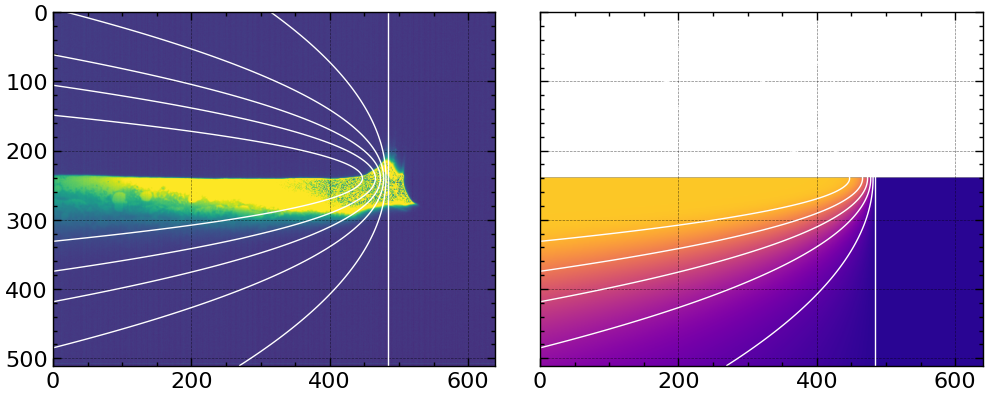

In [14]:
# Custom levels on emissivity field
custom_levels = np.array([0.23, 0.3, 0.4, 0.5, 0.6, 0.70])

# Custom tools array for first order like phenomenological emissivity law
delay_2 = 0.35
upper_limit=240  # 245 top surface : equivalent to 0 mm

y_matrix_pos = (np.arange(0, 512) - upper_limit)*FAC
x_matrix_pos = np.arange(0, 640)*FAC/16.7
time_contribution, depth_contribution = np.meshgrid(
    x_matrix_pos,
    y_matrix_pos
)
mask_prof = np.zeros_like(time_contribution, dtype=bool)
mask_prof[:upper_limit,:]=True  # True == unwanted values

emissivity_field_heterogenous_1 = np.fliplr(
    first_order_emissivity(
        time=time_contribution,
        depth=depth_contribution,
        delay=delay_2,
        eps_non_oxy=0.23,
        eps_oxy=0.73,
        params_tau_evolve=time_constant_parameters
    )
)


# Création de la figure et des sous-graphiques
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6), sharey=True)

# Affichage du premier champ thermique
IMAGE_1 = np.ma.masked_array(CRED_im_dl_raw, mask=mask_prof)
IMAGE_1 = CRED_im_dl_raw
im1 = axes[0].imshow(IMAGE_1, cmap='viridis', vmin=0, vmax=10000)
iso_emi = axes[0].contour(emissivity_field_heterogenous_1, levels=custom_levels, colors='white', linewidths=1)
# axes[0].clabel(iso_emi, inline=True, fontsize=10, fmt='%.2f')

IMAGE_2 = np.ma.masked_array(emissivity_field_heterogenous_1, mask=mask_prof)
im2 = axes[1].imshow(IMAGE_2, cmap='plasma', vmin=0.2, vmax=0.8)
iso_emi = axes[1].contour(emissivity_field_heterogenous_1, levels=custom_levels, colors='white', linewidths=1)
# axes[1].clabel(iso_emi, inline=True, fontsize=10, fmt='%.2f')

plt.subplots_adjust(right=0.9, hspace=0.15, wspace=0.1)
# plt.savefig("../resultats/emissivity_field_two_step_time.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()

##### Calcul de la cartographie thermique

In [15]:
CRED_im_thermo_heterogenous_1 = dl_to_thermo(
    dl_raw=CRED_im_dl_raw,
    nuc_table=array_nuc,
    calibration_table=array_calibration,
    emissivity=emissivity_field_heterogenous_1
    )

#### Champ d'émissivité hétérogène: part 2

In [16]:
No_iteration = 20
emissivity_starts = 0.73

# Initializing dictionary for local results
local_results={}

# Empty array for fixe point method
thermal_images = np.zeros((No_iteration+1, LINES_CRED, COLUMNS_CRED))
emissivity_maps = np.ones((No_iteration+1, LINES_CRED, COLUMNS_CRED))*emissivity_starts

# Load raw image for work
thermal_images[0]=dl_to_thermo(
    dl_raw=CRED_im_dl_raw,
    nuc_table=array_nuc,
    calibration_table=array_calibration,
    emissivity=emissivity_starts
) - 273.15  # Celsius degree thermal maps

for iteration in range(1, No_iteration+1):

    # Update thermal maps
    current_thermo = np.copy(thermal_images[iteration-1])

    # Emissivity map from phenomenological law
    emissivity_maps[iteration]=wagner_inspired_emissivity(
        temperature=current_thermo, 
        depth=depth_contribution, 
        unit='mm',
        block=False,
        evolution='linear',
        eps_min=0.23
    )

    # New thermal image from the phenomenological emissivity field
    thermal_images[iteration] = dl_to_thermo(
        dl_raw=CRED_im_dl_raw,
        nuc_table=array_nuc,
        calibration_table=array_calibration,
        emissivity=emissivity_maps[iteration]
    ) - 273.15  # Celsius degree thermal maps


CRED_im_thermo_heterogenous_2 = thermal_images[No_iteration] + 273.15
emissivity_field_heterogenous_2 = emissivity_maps[No_iteration]

### Résultats

shit 0.1875 mm downwards


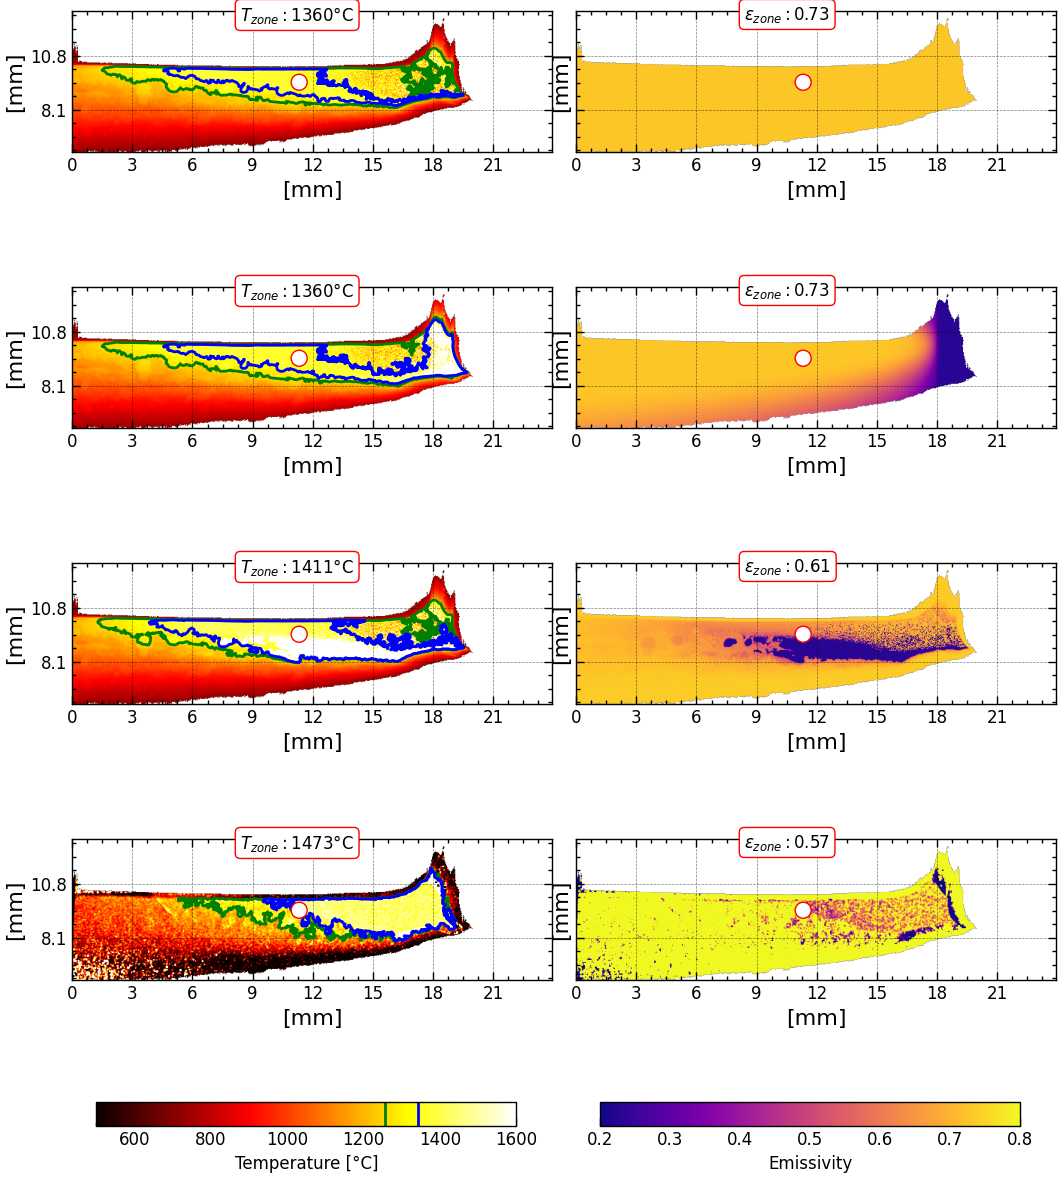

In [23]:
import matplotlib.patches as patches

# Contour and extent setup
x_contour, y_contour, y_contour_inverted, extent,\
      xtick_pixels, ytick_pixels = setup_contour_parameters(COLUMNS_CRED, LINES_CRED, FAC)

# Pyrometer
N = 5
mask_shifted = np.roll(mask_position_pyrometer, shift=N, axis=0)
mask_shifted[:N, :] = False  # Set the first rows to False
print(f"shit {N*FAC} mm downwards")
x_position_pyrometer = np.mean(np.where(mask_shifted)[1])
y_position_pyrometer = np.mean(np.where(mask_shifted)[0])
spot_pyrometer = 0.8/FAC
new_mask_position_pyrometer = np.zeros((512, 640, 4))
new_mask_position_pyrometer[mask_shifted] = [0, 0, 0, 1]

threshold_for_visu = 1000
fake_mask_for_visu = np.nan_to_num(CRED_im_thermo_homogenous, nan=threshold_for_visu)
fake_mask_for_visu = fake_mask_for_visu <= threshold_for_visu
# Next line for full screen visualization
# fake_mask_for_visu = np.zeros_like(CRED_im_thermo_homogenous, dtype=bool)

XIMEA_im_thermo_rescaled_masked = np.copy(XIMEA_im_thermo_rescaled)
XIMEA_im_thermo_rescaled_masked[fake_mask_for_visu]=np.nan
XIMEA_im_emissivity_rescaled_masked = np.ma.masked_where(fake_mask_for_visu, XIMEA_im_emissivity_rescaled)


data = [
    (
        np.ma.masked_array(CRED_im_thermo_homogenous, mask=fake_mask_for_visu), 
        np.ma.masked_array(np.ones_like(CRED_im_thermo_homogenous) * eps0, mask=fake_mask_for_visu)
    ),
    (
        np.ma.masked_array(CRED_im_thermo_heterogenous_1, mask=fake_mask_for_visu), 
        np.ma.masked_array(emissivity_field_heterogenous_1, mask=fake_mask_for_visu)
    ),
    (
        np.ma.masked_array(CRED_im_thermo_heterogenous_2, mask=fake_mask_for_visu),
        np.ma.masked_array(emissivity_field_heterogenous_2, mask=fake_mask_for_visu)
    ),
    (
        XIMEA_im_thermo_rescaled_masked,
        XIMEA_im_emissivity_rescaled_masked        
    )
]


# Création de la figure
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12, 12), sharex=False, sharey=True)

# Ajout des images aux sous-graphiques
for i, (thermal, emissivity) in enumerate(data):
    mean_temp = np.nanmean(thermal[mask_shifted]-273.15)
    mean_emi = np.nanmean(emissivity[mask_shifted])

    im1 = axes[i, 0].imshow(thermal-273.15, cmap='hot', extent=extent, vmin=500, vmax=1600)
    im2 = axes[i, 1].imshow(emissivity, cmap='plasma', extent=extent, vmin=0.2, vmax=0.8)

    # Isotherms detection
    isotherm_sol = measure.find_contours(thermal, T_SOLIDUS)
    isotherm_sol_sorted = sorted(isotherm_sol, key=lambda x: len(x), reverse=True)
    for contour in isotherm_sol_sorted[:1]:
        axes[i, 0].plot(contour[:, 1]*FAC, (LINES_CRED-contour[:, 0])*FAC, color='green', linewidth=2)
    
    isotherm_liq = measure.find_contours(thermal, T_LIQUIDUS)
    isotherm_liq_sorted = sorted(isotherm_liq, key=lambda x: len(x), reverse=True)
    for contour in isotherm_liq_sorted[:1]:
        axes[i, 0].plot(contour[:, 1]*FAC, (LINES_CRED-contour[:, 0])*FAC, color='blue', linewidth=2)

    # Pyrometer position
    for ax in [axes[i, 0], axes[i, 1]]:
        circle = patches.Circle(
            (x_position_pyrometer * FAC, y_position_pyrometer * FAC), 
            spot_pyrometer * FAC / 2, color='white', ec='red', lw=1, 
            fill=True, alpha=1, zorder=3
            )
        ax.add_patch(circle)

    axes[i, 0].annotate(
        r"$T_{zone}:$" + f"{mean_temp:.0f}°C", xy=(0.35, 1.05), xycoords='axes fraction',
        fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', edgecolor='red', facecolor='white')
        )
    axes[i, 1].annotate(
        r"$\varepsilon_{zone}:$" + f"{mean_emi:.2f}", xy=(0.35, 1.05), xycoords='axes fraction',
        fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.3', edgecolor='red', facecolor='white')
        )

# Ajout des labels globaux 
# fig.supxlabel("Largeur [mm]", fontsize=14)
# fig.supylabel("Profondeur [mm]", fontsize=14)
# fig.text(0.5, 0.005, "Largeur [mm]", ha='center', fontsize=12)  # X label sous les colorbars
# fig.text(0.02, 0.5, "Profondeur [mm]", va='center', rotation=90, fontsize=12)  # Y label plus proche des graphes

# Configuration des axs
for ax in axes.flatten():
    ax.set_xticks(xtick_pixels * FAC)
    ax.set_yticks(ytick_pixels * FAC)
    ax.set_xticklabels([f"{x:.0f}" for x in xtick_pixels * FAC], fontsize=12)
    ax.set_yticklabels([f"{y:.1f}" for y in ytick_pixels * FAC], fontsize=12)
    ax.set_xlabel('[mm]')
    ax.set_ylabel('[mm]')
    ax.set_ylim(ymin=6, ymax=13)

# Ajout des colorbars
cbar_ax1 = fig.add_axes([0.10, 0.0, 0.35, 0.02])
cbar_ax2 = fig.add_axes([0.52, 0.0, 0.35, 0.02])
cbar1 = fig.colorbar(im1, cax=cbar_ax1, orientation="horizontal")
cbar2 = fig.colorbar(im2, cax=cbar_ax2, orientation="horizontal")
cbar1.ax.tick_params(labelsize=12) 
cbar2.ax.tick_params(labelsize=12) 
cbar1.set_label('Temperature [°C]', fontsize=12)
cbar2.set_label('Emissivity', fontsize=12)

# Repère colorbar
cbar1.ax.axvline(T_SOLIDUS-273.15, color='g', linewidth=2, linestyle='-')
cbar1.ax.axvline(T_LIQUIDUS-273.15, color='b', linewidth=2, linestyle='-')

plt.subplots_adjust(bottom=0.08, top=0.97, left=0.08, right=0.9, hspace=0.15, wspace=0.05)
# plt.savefig("./resultats/comparaison_4res.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()